### 1. Review the results of the ConvNet model applied to the 2D Kepler (Sun-Earth) configuration. If the results are not satisfactory, provide a detailed analysis and discussion. (60pts)

In [1]:
## DEMO KEPLER DATASET GENERATION CODE

import math
import numpy as np

class Point:
    def __init__(self, x, y, z):
        self.x = x
        self.y = y
        self.z = z

class Body:
    def __init__(self, location, mass, velocity, name=""):
        self.location = location
        self.mass = mass
        self.velocity = velocity
        self.name = name

def run_simulation(bodies, dt=1, steps=10000):
    G = 6.67408e-11

    # Initialize the history of body locations and velocities
    history = [{"name": body.name, "x": [], "y": [], "z": [], "vx": [], "vy": [], "vz": []} for body in bodies]

    for step in range(1, steps + 1):
        # Calculate accelerations
        accelerations = [Point(0, 0, 0) for _ in bodies]
        for i, target_body in enumerate(bodies):
            for j, external_body in enumerate(bodies):
                if i != j:
                    dx = external_body.location.x - target_body.location.x
                    dy = external_body.location.y - target_body.location.y
                    dz = external_body.location.z - target_body.location.z
                    r_squared = dx**2 + dy**2 + dz**2
                    r = math.sqrt(r_squared)
                    factor = G * external_body.mass / r_squared**1.5
                    accelerations[i].x += factor * dx
                    accelerations[i].y += factor * dy
                    accelerations[i].z += factor * dz

        # Update velocities and positions
        for i, body in enumerate(bodies):
            body.velocity.x += accelerations[i].x * dt
            body.velocity.y += accelerations[i].y * dt
            body.velocity.z += accelerations[i].z * dt
            if body.name != 'sun':
                body.location.x += body.velocity.x * dt
                body.location.y += body.velocity.y * dt
                body.location.z += body.velocity.z * dt

        # Record data
        if step % int(1/dt) == 0:
            for i, body in enumerate(bodies):
                hist = history[i]
                hist["x"].append(body.location.x)
                hist["y"].append(body.location.y)
                hist["z"].append(body.location.z)
                hist["vx"].append(body.velocity.x)
                hist["vy"].append(body.velocity.y)
                hist["vz"].append(body.velocity.z)

    return history

def system_P2(batch_size):
    counter = 0
    G = 6.67408e-11
    while True:
      loc1 = np.random.uniform(-5, 5)
      loc2 = np.random.uniform(-5, 5)
      vel1 = np.random.uniform(-5, 5)
      vel2 = np.random.uniform(-5, 5)

      sun = Body(Point(0, 0, 0), 1/G, Point(0, 0, 0), "sun")
      earth = Body(Point(loc1, loc2, 0), 1, Point(vel1, vel2, 0), "earth")

      bodies = [sun, earth]
      burn_steps = 3
      dt = 0.01
      results = run_simulation(bodies, dt=dt, steps=int((1/dt)*(batch_size+burn_steps)+1))

      # Save earth's position & velocity information
      x = np.array(results[1]['x'][burn_steps:])
      y = np.array(results[1]['y'][burn_steps:])
      vx = np.array(results[1]['vx'][burn_steps:])
      vy = np.array(results[1]['vy'][burn_steps:])

      angular_momentum = x * vy - y * vx
      energy = 0.5 * (vx**2 + vy**2) - 1 / np.sqrt(x**2 + y**2)
      mean_angular_momentum = np.mean(angular_momentum)
      mean_energy = np.mean(energy)

      if np.std(angular_momentum) < 1e-3 and np.std(energy) < 1e-3:
          eccentricity = np.sqrt(1 + 2 * (mean_angular_momentum**2) * mean_energy)
          if eccentricity < 0.99:
              break

    state_vectors = np.array([x, y, vx, vy]).T
    labels = np.array([np.array([mean_angular_momentum, mean_energy]) for _ in range(batch_size)])
    return state_vectors, labels

In [ ]:
# YOUR CODE HERE (5pts)

# YOUR DATASET GENERATION CODE HERE 

purpose = "training" # training data
# purpose = "test" # test data

if purpose == "training":
    N = 2#20
    M = 200
elif purpose == "test":
    N = 2#20
    M = 200

# N: Number of groups
# M: Number of data per group (batch size)

data = np.zeros((N, M, 4), dtype=float)
Label = np.zeros((N, M, 2), dtype=float)

for i in range(N):
    state_vectors, labels = system_P2(M)
    data[i, :, :] = state_vectors
    Label[i, :, :] = labels

    print(f"{i}/{N}")

np.save(f"data_kepler_{purpose}.npy", data)
np.save(f"label_kepler_{purpose}.npy", Label)


0/2
1/2


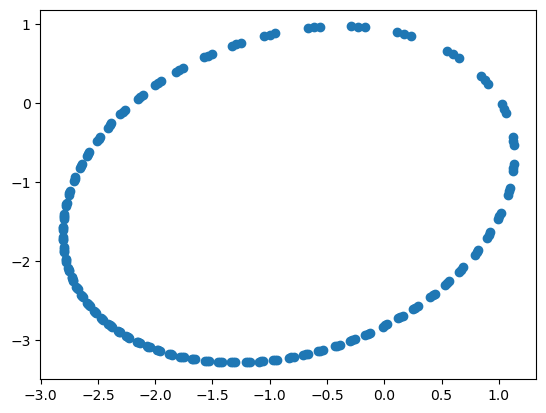

In [ ]:
import matplotlib.pyplot as plt

i = 0
plt.scatter(data[i, :, 0], data[i, :, 1])
plt.show()

In [10]:
# YOUR CODE HERE (15pts)

# RE-DESIGN OR USE CONSERVNET
# YOUR NEURAL NETWORK CODE HERE

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"device: {device}")


class ConservNet(nn.Module):
    def __init__(self, num):
        # For Kepler problem, num == 4 (x, y, vx, vy)
        super().__init__()
        hidden_size = 320
        self.net = nn.Sequential(
            nn.Linear(num, hidden_size),
            nn.Mish(),
            nn.Linear(hidden_size, hidden_size),
            nn.Mish(),
            nn.Linear(hidden_size, hidden_size),
            nn.Mish(),
            nn.Linear(hidden_size, hidden_size),
            nn.Mish(),
            nn.Linear(hidden_size, 1,  bias=False)
        )

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data, gain = nn.init.calculate_gain('relu'))
                if m.bias is not None:
                    m.bias.data.zero_()

    def forward(self, x):
        return self.net(x)
    

class KeplerDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    
    def __len__(self):
        return self.data.size(0)
    

    def __getitem__(self, idx):
        return self.data[idx]

device: cpu


In [2]:
# YOUR CODE HERE (15pts)

# RE-DESIGN OR USE CONSERVNET
# YOUR LOSS FUNCTION CODE HERE


def Loss(pred, pred_noise, Q=1):
    L_var = torch.var(pred)
    L_noise = torch.abs(Q - torch.var(pred_noise))
    
    return L_var + L_noise

In [ ]:
# YOUR CODE HERE (5pts)

# YOUR NEURAL NETWORK TRAINING CODE HERE

data = np.load("data_kepler_training.npy")
N, M, c = np.shape(data)
# N: number of groups
# M: number of states per trajectory
# c: number of data per state. In the Kepler problem, c == 4 (x, y, vx, vy)

dataSet = KeplerDataset(data)
loader = DataLoader(dataSet, batch_size=1, shuffle=True) # 1 trajectory = 1 batch

model = ConservNet(c).to(device)
epochs = 20000
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=0)
loss_list = np.zeros(epochs, dtype=float)
R = 1 # noise normalization

print("Training start")

model.train()
for epoch in range(epochs):
    loss_per_running = 0

    for data_batch in loader:
        data_batch = data_batch.to(device)

        optimizer.zero_grad()
        noiseDirection = nn.functional.normalize(torch.randn_like(data_batch), p=2, dim=1)
        noiseRadius = torch.rand(data_batch.size(0), 1, device=data_batch.device)*R
        noise = noiseDirection*noiseRadius

        pred1 = model(data_batch) # input
        pred2 = model(data_batch + noise) # input + noise

        loss = Loss(pred1, pred2)
        loss.backward()
        optimizer.step()

        loss_per_running += loss.item()

    loss_list[epoch] = loss_per_running/len(loader)

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss_list[epoch]}", flush=True)


torch.save(model.state_dict(), "conservnet_kepler.pt")

In [74]:
# YOUR CODE HERE (5pts)

# YOUR VISUALIZATION CODE HERE

import matplotlib.pyplot as plt
import scipy.stats as stats

data = torch.tensor(np.load("data/data_kepler_test.npy"), dtype=torch.float32).to(device)
label = np.load("data/label_kepler_test.npy")
N, M, c = data.shape
# N: number of groups
# M: number of states per trajectory
# c: number of data per state. In the Kepler problem, c == 4 (x, y, vx, vy)

pred = torch.zeros((N, M), dtype=torch.float32)

model = ConservNet(c).to(device)
model.load_state_dict(torch.load("data/conservnet_kepler.pt", weights_only=True, map_location=torch.device(device)))

model.eval()
with torch.no_grad():
    for i in range(N):
        pred[i, :] = model(data[i, :, :]).squeeze()

pred = pred.cpu().numpy()

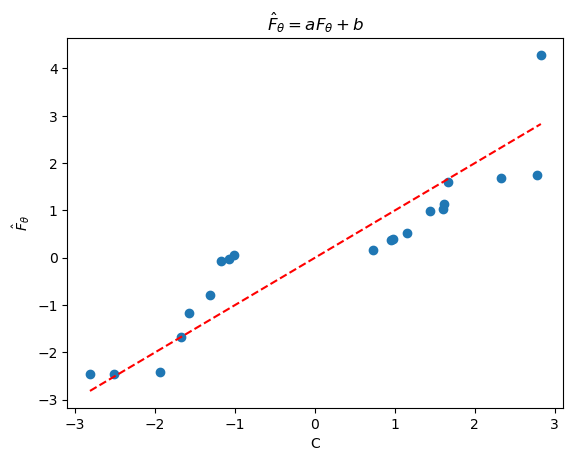

a=0.39420663746471724, b=-0.8312808595339618
r_value=0.9170754465122509, p_value=1.2994207523644101e-08, std_err=0.040396504492253744


In [109]:
Q = label[:, :, 0][:, 0]
pred_mean = np.mean(pred, axis=1)

F = np.sort(pred_mean)
C = np.sort(Q)

slope, intercept, r, p, std_err = stats.linregress(F, C)

plt.plot(C, C, '--r')
plt.scatter(C, slope*F + intercept)
plt.xlabel("C")
plt.ylabel("$\\hat{F}_\\theta$")
plt.title("$\\hat{F}_\\theta=aF_\\theta+b$")

plt.show()
print(f"a={slope}, b={intercept}")
print(f"r_value={r}, p_value={p}, std_err={std_err}")

### Discuss the results (15pts)

DISCUSSING THE ANALYSIS RESULTS (in 500 words, include graphics or tables by using markdown is fine)

The red dashed line is $\hat{F}_\theta=C$ and blue dots indicate $\hat{F}_\theta=aF_\theta+b$. Here, $F_\theta$ is the mean value of prediction for each trajectories and $C$ is the value of corresponding conserved quantity. If blue dots are localized near the red dashed line, this means that the identity $\hat{F}_\theta=C$ is true. In our result, $r\approx0.92$ and $p\approx1.3\times10^{-8}$ which means there is a strong and statistically significant linear relationship between $\hat{F}_\theta$ and $C$.

### 2. Explore potential methods or strategies to further enhance the performance of PINNs. (review articles, or just consideration is fine) (40pts)

REVIEW RECENTLY METHODS OR STRATEGIES (in 500 words, include graphics or tables by using markdown is fine, ADD REFERENCE)

In addition to PINN, there is another concept called Operator Learning. Let us consider a differential equation 
$$
\begin{gather}
\mathcal{L}(u)=f
\end{gather}
$$ 
with solution $u(x)$, differetial operator $\mathcal{L}$ and source term $f(x)$. If we know $\mathcal{L}^{-1}$, we can find solution as 
$$\begin{gather}
u(x)=\mathcal{L}^{-1}(f(x))
\end{gather}
$$. 
This method involves training a neural netwotk to learn the $\mathcal{L}^{-1}$ in order to obtain the solution. In this framework, the primary learning target is the operator mapping
$$
\begin{gather}
\mathcal{L}^{-1}:f\to u
\end{gather}
$$. 
Therefore, once trained, neural network can efficiently predict solutions for unknown source function $f(x)$ while exhibiting relative independence from mesh step size.

One of the earliest models is DeepONet [[Lu et al., 2021](https://doi.org/10.1038/s42256-021-00302-5)]. DeepONet has limitations in generalizing to irregular meshes or complex geometries becasue the input funtion is represented by sampled points. To address these limitations, the Fourier Neural Operator (FNO) [[Li et al., 2021](https://doi.org/10.48550/arXiv.2010.08895)] was proposed, which learns operators in the frequency domain and provides robust multi-scale representations. In addition, the Graph Neural Operator (GNO) [[Li et al., 2021](https://doi.org/10.48550/arXiv.2003.03485)] represents PDE domains as graph structure, ensabling neural operators to handle irregular meshes or complex geometries more effectively.

However, Operator Learning is data-driven and do not explicitly enforce the PDE during training. As a result, there is a possibility of physics violations or broken conservation laws. To overcome these limitations, many recent studies attempt to combine PINN and Operator Learning frameworks, such as Physics-Informed Neural Operators [[Li et al., 2023](https://doi.org/10.48550/arXiv.2111.03794)]. These hybrid approaches aim to improve physical consistency while maintaining the scalability and efficiency of operator learning methods.